
Random_state:  13
    Age  Male(0) Female(1)   BMI  Smoking  Charlson Comorbidity Index  \
40   96                  1  18.1        0                           5   
3    59                  1  40.0        0                           1   
36   59                  1  40.3        2                           7   
27   76                  0  34.7        0                           5   
31   81                  0  38.0        1                           4   
28   89                  1  21.4        1                           6   
29   59                  1  40.3        2                           7   
26   76                  1  31.4        0                           4   
18   78                  1  20.9        1                           5   
12   22                  0  19.4        0                           0   
21   87                  0  26.3        0                           7   
13   77                  0  34.7        1                           6   
16   73                  1  25.6

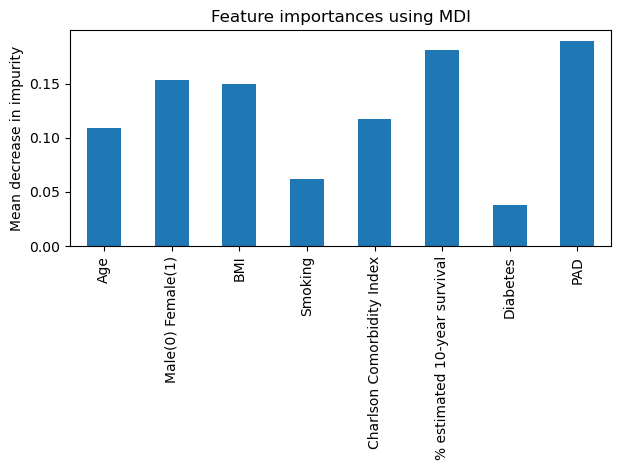

[[ 0.8290896   0.21701519]
 [ 0.5663324   0.4706491 ]
 [ 0.08786566  0.8947669 ]
 [ 0.4106654   0.5088193 ]
 [ 0.6159732   0.42515126]
 [ 0.36778638  0.5888561 ]
 [ 0.40074918  0.5607751 ]
 [ 0.3912357   0.57638454]
 [ 0.15139933  0.8452334 ]
 [-0.04191365  1.0408865 ]
 [ 0.13125671  0.86020947]
 [ 0.68756574  0.3650866 ]
 [ 0.49401018  0.5465795 ]]
[[ True False]
 [ True False]
 [False  True]
 [False  True]
 [ True False]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [ True False]
 [False  True]]


<Figure size 40000x12000 with 0 Axes>

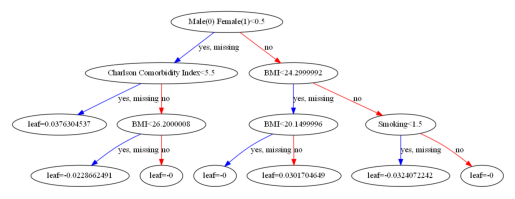

--------------------------------------------------------------------------------------------------


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model

Treatment=pd.read_csv("../dissertation/demographic atra.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=73
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.3, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
W_tree=1

print(X_train)


clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="exact",
                 objective="reg:pseudohubererror",
                  eta=0.09,
                 # max_depth=4,
                 # subsample=0.9,
                  colsample_bytree=0.7,
                  colsample_bylevel=0.9,
                # colsample_bynode=0.6,
                  reg_lambda=0.8,
                  reg_alpha=0.4,
                  rate_drop=1,
                  skip_drop=0.4,
                  one_drop=1,
                  sample_type="weighted",
                  
    )



clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["non-healing","healing"]


#Which_data=df_y_test
Which_data=df_y

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)